In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(
    "../data/processed/merged_projects.csv",
    low_memory=False
)

print("Shape:", df.shape)
print(df.head())

Shape: (18601, 34)
  project_code                                       project_name  \
0       612786  Construction of New Domestic Terminal Building...   
1       701107  Construction of New Integrated Terminal Buildi...   
2       701121  Construction of New Domestic Terminal Building...   
3       706724  Guwahati Airport New Integrated Terminal Build...   
4       612183          Development of New Civil Enclave at Bihta   

                             agency           state date_of_approval  \
0  Airport Authority of India [AAI]  Andhra Pradesh       2023-03-01   
1  Airport Authority of India [AAI]  Andhra Pradesh       2020-06-01   
2  Airport Authority of India [AAI]  Andhra Pradesh       2022-12-01   
3    Adani Airport Holdings Limited           Assam       2016-12-01   
4  Airport Authority of India [AAI]           Bihar       2024-08-01   

   start_date actual_doc  target_doc revised_doc  original_cost_cr  ...  \
0  2024-01-01        NaN  2026-01-01  2026-03-01          

In [2]:
print("Before removing duplicates:", df.shape)

df = df.drop_duplicates().copy()

print("After removing duplicates:", df.shape)

Before removing duplicates: (18601, 34)
After removing duplicates: (15376, 34)


In [3]:
project_counts = df["project_code"].value_counts()

print("Unique projects:", df["project_code"].nunique())
print("\nProject observation statistics:")
print(project_counts.describe())

print("\nMost frequent projects:")
print(project_counts.head(10))

Unique projects: 2369

Project observation statistics:
count    2369.000000
mean        6.490502
std         3.523571
min         1.000000
25%         4.000000
50%         6.000000
75%         8.000000
max        13.000000
Name: count, dtype: float64

Most frequent projects:
project_code
612786    13
602181    13
602593    13
701349    13
611586    13
604833    13
602535    13
709755    13
400261    13
611509    13
Name: count, dtype: int64


In [4]:
target = "cost_overrun_pct"

print(df[target].describe())
print("\nMissing target values:", df[target].isna().sum())

count    15158.000000
mean         0.108631
std          0.597805
min         -0.999581
25%          0.000000
50%          0.000000
75%          0.016804
max         19.210121
Name: cost_overrun_pct, dtype: float64

Missing target values: 218


In [5]:
df = df.dropna(subset=[target]).copy()

print("Shape after removing missing target:", df.shape)

Shape after removing missing target: (15158, 34)


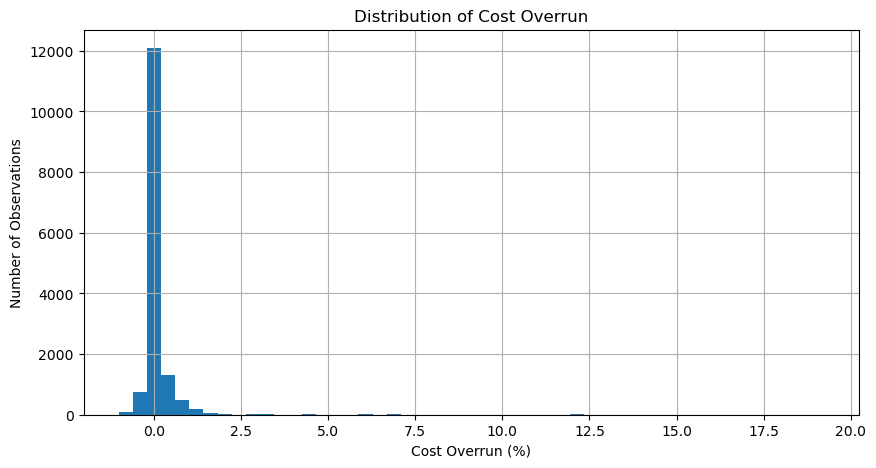

Negative overrun: 2310
Zero overrun: 8667
Positive overrun: 4181


In [6]:
plt.figure(figsize=(10, 5))

df["cost_overrun_pct"].hist(bins=50)

plt.xlabel("Cost Overrun (%)")
plt.ylabel("Number of Observations")
plt.title("Distribution of Cost Overrun")

plt.show()

print("Negative overrun:", (df["cost_overrun_pct"] < 0).sum())
print("Zero overrun:", (df["cost_overrun_pct"] == 0).sum())
print("Positive overrun:", (df["cost_overrun_pct"] > 0).sum())

In [7]:
features = [
    "project_code",
    "original_cost_cr",
    "cumulative expenditure in rs. crore",
    "physical progress (in percentage)",
    "agency",
    "state",
    "ministry",
    "sector",
    "status",
    "date_of_approval",
    "start_date",
    "target_doc",
    "expenditure_to_original_cost_ratio",
    "expenditure_progress_mismatch",
    "high_spend_low_progress_flag",
    "negative_expenditure_flag",
    "cost_overrun_pct"
]

df_model = df[features].copy()

print("df_model shape:", df_model.shape)
print("\nColumns:")
print(df_model.columns.tolist())

df_model shape: (15158, 17)

Columns:
['project_code', 'original_cost_cr', 'cumulative expenditure in rs. crore', 'physical progress (in percentage)', 'agency', 'state', 'ministry', 'sector', 'status', 'date_of_approval', 'start_date', 'target_doc', 'expenditure_to_original_cost_ratio', 'expenditure_progress_mismatch', 'high_spend_low_progress_flag', 'negative_expenditure_flag', 'cost_overrun_pct']


In [8]:
# Target
y = df_model["cost_overrun_pct"].copy()

# Features
X = df_model.drop(columns=["cost_overrun_pct", "project_code"]).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (15158, 15)
y shape: (15158,)


In [9]:
date_columns = [
    "date_of_approval",
    "start_date",
    "target_doc"
]

# Convert dates
for col in date_columns:
    X[col] = pd.to_datetime(X[col], errors="coerce")

# Extract useful date features
X["approval_year"] = X["date_of_approval"].dt.year
X["approval_month"] = X["date_of_approval"].dt.month

X["start_year"] = X["start_date"].dt.year
X["start_month"] = X["start_date"].dt.month

X["target_year"] = X["target_doc"].dt.year
X["target_month"] = X["target_doc"].dt.month

# Planned project duration
X["planned_duration_days"] = (
    X["target_doc"] - X["start_date"]
).dt.days

# Remove original date columns
X = X.drop(columns=date_columns)

print("X shape:", X.shape)
print(X.head())

X shape: (15158, 19)
   original_cost_cr  cumulative expenditure in rs. crore  \
0            265.91                                76.65   
1            611.80                               523.14   
2            347.15                               109.62   
3           1712.00                              2456.07   
4           1413.00                                 0.00   

   physical progress (in percentage)                            agency  \
0                               42.0  Airport Authority of India [AAI]   
1                               86.0  Airport Authority of India [AAI]   
2                               64.0  Airport Authority of India [AAI]   
3                               94.0    Adani Airport Holdings Limited   
4                                1.0  Airport Authority of India [AAI]   

            state                    ministry  \
0  Andhra Pradesh  Ministry of Civil Aviation   
1  Andhra Pradesh  Ministry of Civil Aviation   
2  Andhra Pradesh  Ministr

In [10]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numeric_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numeric_features))

Categorical features:
['agency', 'state', 'ministry', 'sector', 'status']

Numerical features:
['original_cost_cr', 'cumulative expenditure in rs. crore', 'physical progress (in percentage)', 'expenditure_to_original_cost_ratio', 'expenditure_progress_mismatch', 'high_spend_low_progress_flag', 'negative_expenditure_flag', 'approval_year', 'approval_month', 'start_year', 'start_month', 'target_year', 'target_month', 'planned_duration_days']

Number of categorical features: 5
Number of numerical features: 14


In [11]:
groups = df_model["project_code"].astype(str)

print("Unique projects:", groups.nunique())

Unique projects: 2240


In [12]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (12172, 19)
X_test : (2986, 19)
y_train: (12172,)
y_test : (2986,)


In [13]:
train_projects = set(groups.iloc[train_idx])
test_projects = set(groups.iloc[test_idx])

overlap = train_projects.intersection(test_projects)

print("Training projects:", len(train_projects))
print("Testing projects:", len(test_projects))
print("Overlapping projects:", len(overlap))

Training projects: 1792
Testing projects: 448
Overlapping projects: 0


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Numerical preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [15]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

print("XGBoost model created successfully.")

XGBoost model created successfully.


In [16]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

print("Complete pipeline created successfully.")

Complete pipeline created successfully.


In [17]:
pipeline.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [18]:
y_pred = pipeline.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 2986


In [19]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Performance")
print("-----------------")
print("R²   :", r2)
print("MAE  :", mae)
print("RMSE :", rmse)

Model Performance
-----------------
R²   : 0.5051438097193792
MAE  : 0.17722824779260146
RMSE : 0.6304647797402768


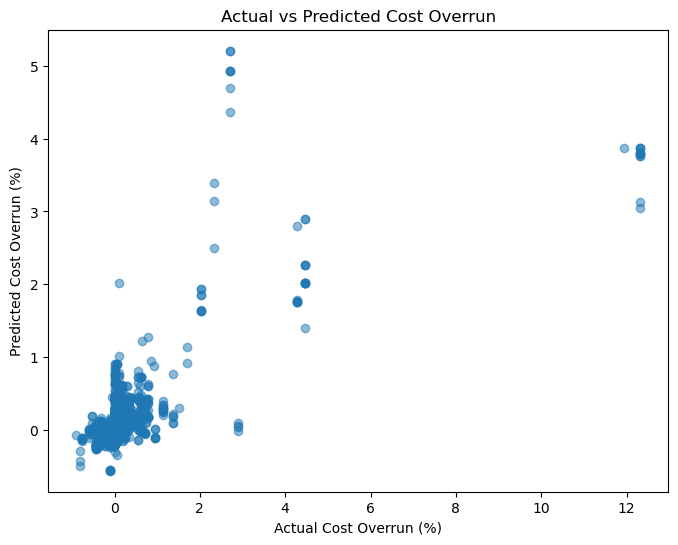

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Cost Overrun (%)")
plt.ylabel("Predicted Cost Overrun (%)")
plt.title("Actual vs Predicted Cost Overrun")

plt.show()

In [21]:
feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = pipeline.named_steps[
    "model"
].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

print(feature_importance.head(20))

                                               feature  importance
317  cat__state_Multi-States (Gujarat, Madhya Pradesh)    0.160902
4                   num__expenditure_progress_mismatch    0.044632
407                          cat__sector_Waste & Water    0.044605
131                  cat__agency_Irrigation and CAD-TG    0.044435
147    cat__agency_Ministry of Housing & Urban Affairs    0.044112
90   cat__agency_Department of water resources-MH - II    0.038372
383                    cat__ministry_Ministry of Power    0.034060
49                           cat__agency_CAOCWR WR mor    0.026131
9                                      num__start_year    0.024030
3              num__expenditure_to_original_cost_ratio    0.021999
365                               cat__state_Telangana    0.016938
373     cat__ministry_Department of Telecommunications    0.013908
217  cat__agency_Satluj Jal Vidyut Nigam [SJVN] The...    0.013712
359                               cat__state_PAN India    0.01

In [22]:
import os

os.makedirs("../data/models", exist_ok=True)

In [23]:
import joblib

joblib.dump(
    pipeline,
    "../data/models/cost_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [24]:
import json

metrics = {
    "r2": float(r2),
    "mae": float(mae),
    "rmse": float(rmse)
}

with open(
    "../data/models/cost_model_metrics.json",
    "w"
) as f:
    json.dump(metrics, f, indent=4)

print("Metrics saved successfully.")
print(metrics)

Metrics saved successfully.
{'r2': 0.5051438097193792, 'mae': 0.17722824779260146, 'rmse': 0.6304647797402768}


In [25]:
print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


R²: 0.5051438097193792
MAE: 0.17722824779260146
RMSE: 0.6304647797402768


In [26]:
import os

print(os.path.exists("../data/models/cost_model.pkl"))
print(os.path.exists("../data/models/cost_model_metrics.json"))

True
True


In [29]:
# ============================================================
# NEW PROJECT - COST OVERRUN PREDICTION
# ============================================================

import pandas as pd
import numpy as np

print("===================================")
print("   NEW PROJECT COST PREDICTION")
print("===================================")

# ------------------------------------------------------------
# 1. USER INPUTS
# ------------------------------------------------------------

original_cost = float(
    input("Enter original project cost (₹ crore): ")
)

cumulative_expenditure = float(
    input("Enter cumulative expenditure (₹ crore): ")
)

physical_progress = float(
    input("Enter physical progress (%): ")
)

agency = input("Enter agency: ")
state = input("Enter state: ")
ministry = input("Enter ministry: ")
sector = input("Enter sector: ")

status = input(
    "Enter project status (e.g. Ongoing): "
)

date_of_approval = input(
    "Enter date of approval (YYYY-MM-DD): "
)

start_date = input(
    "Enter project start date (YYYY-MM-DD): "
)

target_doc = input(
    "Enter target completion date (YYYY-MM-DD): "
)


# ------------------------------------------------------------
# 2. CALCULATE DERIVED FEATURES
# ------------------------------------------------------------

# Expenditure / original cost ratio
if original_cost != 0:
    expenditure_to_original_cost_ratio = (
        cumulative_expenditure / original_cost
    )
else:
    expenditure_to_original_cost_ratio = 0


# Expenditure-progress mismatch
expenditure_progress_mismatch = (
    expenditure_to_original_cost_ratio
    - (physical_progress / 100)
)


# High-spend / low-progress flag
if (
    expenditure_to_original_cost_ratio > 0.80
    and physical_progress < 50
):
    high_spend_low_progress_flag = 1
else:
    high_spend_low_progress_flag = 0


# Negative expenditure flag
if cumulative_expenditure < 0:
    negative_expenditure_flag = 1
else:
    negative_expenditure_flag = 0


# ------------------------------------------------------------
# 3. CREATE INPUT DATAFRAME
# ------------------------------------------------------------

new_project = pd.DataFrame([{
    "original_cost_cr": original_cost,

    "cumulative expenditure in rs. crore":
        cumulative_expenditure,

    "physical progress (in percentage)":
        physical_progress,

    "agency": agency,
    "state": state,
    "ministry": ministry,
    "sector": sector,
    "status": status,

    "date_of_approval": date_of_approval,
    "start_date": start_date,
    "target_doc": target_doc,

    "expenditure_to_original_cost_ratio":
        expenditure_to_original_cost_ratio,

    "expenditure_progress_mismatch":
        expenditure_progress_mismatch,

    "high_spend_low_progress_flag":
        high_spend_low_progress_flag,

    "negative_expenditure_flag":
        negative_expenditure_flag
}])


# ------------------------------------------------------------
# 4. DATE FEATURES
# ------------------------------------------------------------

new_project["date_of_approval"] = pd.to_datetime(
    new_project["date_of_approval"],
    errors="coerce"
)

new_project["start_date"] = pd.to_datetime(
    new_project["start_date"],
    errors="coerce"
)

new_project["target_doc"] = pd.to_datetime(
    new_project["target_doc"],
    errors="coerce"
)


# Missingness indicators
new_project["date_of_approval_is_missing"] = (
    new_project["date_of_approval"].isna().astype(int)
)

new_project["start_date_is_missing"] = (
    new_project["start_date"].isna().astype(int)
)

new_project["target_doc_is_missing"] = (
    new_project["target_doc"].isna().astype(int)
)

# These were missing in a new project because they are
# post-outcome fields and are not entered by the user.
new_project["actual_doc_is_missing"] = 1
new_project["revised_doc_is_missing"] = 1
new_project["revised_cost_cr_is_missing"] = 1


# Ministry missing indicator
new_project["ministry_is_missing"] = (
    new_project["ministry"].isna().astype(int)
)


# Date-derived features
new_project["approval_year"] = (
    new_project["date_of_approval"].dt.year
)

new_project["approval_month"] = (
    new_project["date_of_approval"].dt.month
)

new_project["start_year"] = (
    new_project["start_date"].dt.year
)

new_project["start_month"] = (
    new_project["start_date"].dt.month
)

new_project["target_year"] = (
    new_project["target_doc"].dt.year
)

new_project["target_month"] = (
    new_project["target_doc"].dt.month
)

new_project["planned_duration_days"] = (
    new_project["target_doc"]
    - new_project["start_date"]
).dt.days


# Remove original date columns
new_project = new_project.drop(
    columns=[
        "date_of_approval",
        "start_date",
        "target_doc"
    ]
)


# ------------------------------------------------------------
# 5. MATCH THE TRAINED MODEL'S FEATURES
# ------------------------------------------------------------

expected_features = pipeline.named_steps[
    "preprocessor"
].feature_names_in_

for column in expected_features:
    if column not in new_project.columns:
        new_project[column] = np.nan

new_project = new_project[
    expected_features
]


# ------------------------------------------------------------
# 6. MAKE XGBOOST PREDICTION
# ------------------------------------------------------------

predicted_overrun = pipeline.predict(
    new_project
)[0]


# ------------------------------------------------------------
# 7. CALCULATE ESTIMATED COST
# ------------------------------------------------------------

# Uses whatever ORIGINAL COST the user entered.
estimated_overrun = (
    original_cost
    * predicted_overrun
    / 100
)

estimated_revised_cost = (
    original_cost
    + estimated_overrun
)


# ------------------------------------------------------------
# 8. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n===================================")
print("       COST OVERRUN PREDICTION")
print("===================================")

print(
    f"Original Cost: ₹{original_cost:.2f} crore"
)

print(
    f"Predicted Cost Overrun: "
    f"{predicted_overrun:.2f}%"
)

print(
    f"Estimated Additional Cost: "
    f"₹{estimated_overrun:.2f} crore"
)

print(
    f"Estimated Revised Cost: "
    f"₹{estimated_revised_cost:.2f} crore"
)

print("===================================")

   NEW PROJECT COST PREDICTION


Enter original project cost (₹ crore):  234
Enter cumulative expenditure (₹ crore):  62
Enter physical progress (%):  38
Enter agency:  Augmentation of Transformation Capacity at Bhuj-II PS [GIS]
Enter state:  Gujurat
Enter ministry:  Ministry of Power
Enter sector:  Electricity Generation
Enter project status (e.g. Ongoing):  Ongoing
Enter date of approval (YYYY-MM-DD):  2024/11/01
Enter project start date (YYYY-MM-DD):  2024/12/01
Enter target completion date (YYYY-MM-DD):  2026/12/01



       COST OVERRUN PREDICTION
Original Cost: ₹234.00 crore
Predicted Cost Overrun: -0.02%
Estimated Additional Cost: ₹-0.04 crore
Estimated Revised Cost: ₹233.96 crore


In [1]:
import pandas as pd

test_data = [
    {
        "original_cost_cr": 300,
        "cumulative expenditure in rs. crore": 120,
        "physical progress (in percentage)": 40,
        "agency": "Airport Authority of India",
        "state": "Andhra Pradesh",
        "ministry": "Ministry of Civil Aviation",
        "sector": "Transport",
        "status": "Ongoing",
        "date_of_approval": "2023-01-15",
        "start_date": "2023-06-01",
        "target_doc": "2027-06-01"
    },
    {
        "original_cost_cr": 500,
        "cumulative expenditure in rs. crore": 350,
        "physical progress (in percentage)": 60,
        "agency": "NHAI",
        "state": "Maharashtra",
        "ministry": "Ministry of Road Transport and Highways",
        "sector": "Transport",
        "status": "Ongoing",
        "date_of_approval": "2022-04-10",
        "start_date": "2022-10-01",
        "target_doc": "2026-10-01"
    },
    {
        "original_cost_cr": 1000,
        "cumulative expenditure in rs. crore": 700,
        "physical progress (in percentage)": 55,
        "agency": "CPWD",
        "state": "Delhi",
        "ministry": "Ministry of Housing and Urban Affairs",
        "sector": "Urban Development",
        "status": "Ongoing",
        "date_of_approval": "2021-03-20",
        "start_date": "2021-09-01",
        "target_doc": "2027-09-01"
    }
]

test_df = pd.DataFrame(test_data)

# Save as CSV
test_df.to_csv("test_cost_data.csv", index=False)

print("CSV file created successfully!")
print(test_df)

CSV file created successfully!
   original_cost_cr  cumulative expenditure in rs. crore  \
0               300                                  120   
1               500                                  350   
2              1000                                  700   

   physical progress (in percentage)                      agency  \
0                                 40  Airport Authority of India   
1                                 60                        NHAI   
2                                 55                        CPWD   

            state                                 ministry             sector  \
0  Andhra Pradesh               Ministry of Civil Aviation          Transport   
1     Maharashtra  Ministry of Road Transport and Highways          Transport   
2           Delhi    Ministry of Housing and Urban Affairs  Urban Development   

    status date_of_approval  start_date  target_doc  
0  Ongoing       2023-01-15  2023-06-01  2027-06-01  
1  Ongoing       2022-

In [3]:
# ============================================================
# RECREATE TEST SET AND SAVE THE 20% TEST DATA
# ============================================================

import pandas as pd
import os
from sklearn.model_selection import GroupShuffleSplit

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

df = pd.read_csv(
    "../data/processed/merged_projects.csv",
    low_memory=False
)

# Remove exact duplicate rows
df = df.drop_duplicates().copy()

print("Dataset shape:", df.shape)


# ------------------------------------------------------------
# 2. CREATE MODEL DATA
# ------------------------------------------------------------

# Keep only rows where target is available
df_model = df.dropna(
    subset=["cost_overrun_pct"]
).copy()

print("Rows available for modelling:", len(df_model))


# ------------------------------------------------------------
# 3. CREATE X AND Y
# ------------------------------------------------------------

features = [
    "project_code",
    "original_cost_cr",
    "cumulative expenditure in rs. crore",
    "physical progress (in percentage)",
    "agency",
    "state",
    "ministry",
    "sector",
    "status",
    "date_of_approval",
    "start_date",
    "target_doc",
    "expenditure_to_original_cost_ratio",
    "expenditure_progress_mismatch",
    "high_spend_low_progress_flag",
    "negative_expenditure_flag",
    "cost_overrun_pct"
]

X = df_model[
    features
].copy()

y = df_model[
    "cost_overrun_pct"
].copy()


# ------------------------------------------------------------
# 4. REMOVE TARGET FROM X
# ------------------------------------------------------------

X = X.drop(
    columns=["cost_overrun_pct"]
)


# ------------------------------------------------------------
# 5. REMOVE PROJECT CODE FROM MODEL FEATURES
# ------------------------------------------------------------

groups = df_model[
    "project_code"
].astype(str)

X = X.drop(
    columns=["project_code"]
)


# ------------------------------------------------------------
# 6. DATE FEATURE ENGINEERING
# ------------------------------------------------------------

date_columns = [
    "date_of_approval",
    "start_date",
    "target_doc"
]

for col in date_columns:
    X[col] = pd.to_datetime(
        X[col],
        errors="coerce"
    )

X["approval_year"] = (
    X["date_of_approval"].dt.year
)

X["approval_month"] = (
    X["date_of_approval"].dt.month
)

X["start_year"] = (
    X["start_date"].dt.year
)

X["start_month"] = (
    X["start_date"].dt.month
)

X["target_year"] = (
    X["target_doc"].dt.year
)

X["target_month"] = (
    X["target_doc"].dt.month
)

X["planned_duration_days"] = (
    X["target_doc"]
    - X["start_date"]
).dt.days

X = X.drop(
    columns=date_columns
)


# ------------------------------------------------------------
# 7. PROJECT-LEVEL 80/20 SPLIT
# ------------------------------------------------------------

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups=groups
    )
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()


# ------------------------------------------------------------
# 8. GET ORIGINAL TEST ROWS
# ------------------------------------------------------------

test_data = df_model.iloc[
    test_idx
].copy()


# ------------------------------------------------------------
# 9. CREATE TEST FOLDER
# ------------------------------------------------------------

os.makedirs(
    "../data/test",
    exist_ok=True
)


# ------------------------------------------------------------
# 10. SAVE TEST CSV
# ------------------------------------------------------------

test_data.to_csv(
    "../data/test/test_cost_data.csv",
    index=False
)


# ------------------------------------------------------------
# 11. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n===================================")
print("       TEST DATA SAVED")
print("===================================")

print(
    f"Training rows: {len(X_train)}"
)

print(
    f"Testing rows: {len(X_test)}"
)

print(
    f"Test projects: "
    f"{groups.iloc[test_idx].nunique()}"
)

print(
    "\nSaved to:"
)

print(
    "../data/test/test_cost_data.csv"
)

Dataset shape: (15376, 34)
Rows available for modelling: 15158

       TEST DATA SAVED
Training rows: 12172
Testing rows: 2986
Test projects: 448

Saved to:
../data/test/test_cost_data.csv


In [4]:
# Create the 20% test data from the same project-level split
test_data = df_model.iloc[test_idx].copy()

test_data.to_csv(
    "../data/test/test_cost_data.csv",
    index=False
)

print("New test CSV created successfully!")
print("Rows:", len(test_data))

New test CSV created successfully!
Rows: 2986
